In [3]:
import kagglehub
import os
import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


In [5]:
dataset = os.path.join(path, "chest_xray")

In [6]:
train = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(dataset, "train"),
    image_size=(150,150),
    batch_size=32
)

Found 5216 files belonging to 2 classes.


In [7]:
# Save class names here
class_names = train.class_names

test = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(dataset, "test"),
    image_size=(150,150),
    batch_size=32
)

normalization = tf.keras.layers.Rescaling(1./255)

train = train.map(lambda x, y: (normalization(x), y))
test = test.map(lambda x, y: (normalization(x), y))

Found 624 files belonging to 2 classes.


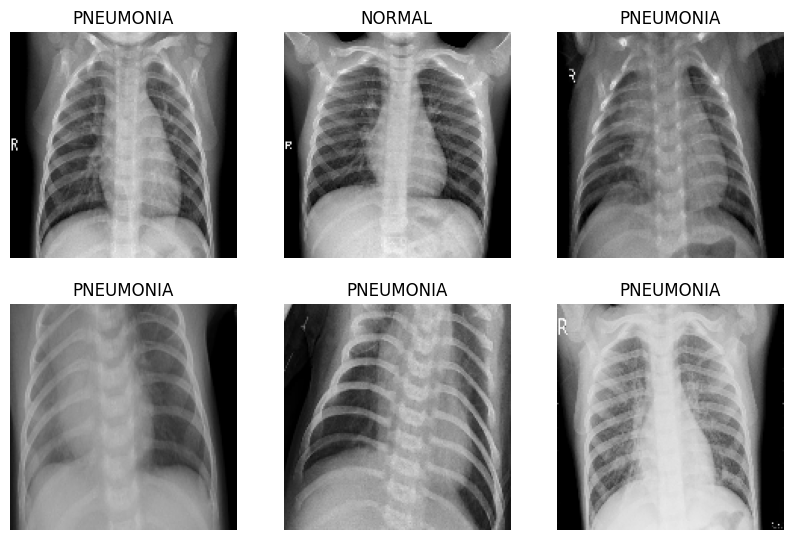

In [8]:
for images, labels in train.take(1):
    plt.figure(figsize=(10,10))

    for i in range(6):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.show()

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train,
    epochs=8
)

Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.8871 - loss: 0.3102
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.9640 - loss: 0.0968
Epoch 3/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.9701 - loss: 0.0761
Epoch 4/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.9803 - loss: 0.0524
Epoch 5/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.9854 - loss: 0.0382
Epoch 6/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.9948 - loss: 0.0183
Epoch 7/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.9921 - loss: 0.0193
Epoch 8/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.9950 - loss: 0.0128


In [12]:
loss, accuracy = model.evaluate(test)

print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 529ms/step - accuracy: 0.7532 - loss: 1.9448
Test Accuracy: 0.7532051205635071


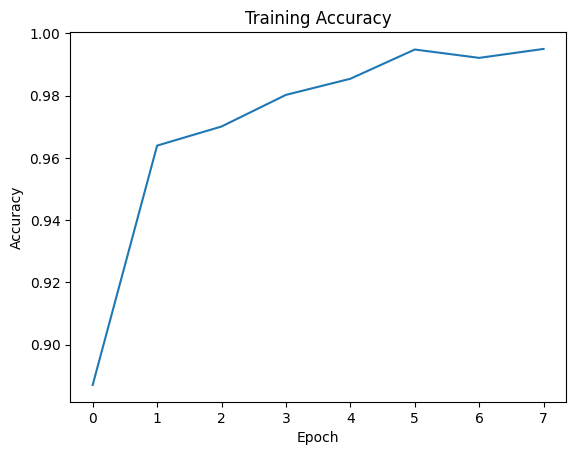

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [14]:
for images, labels in test.take(1):

    prediction = model.predict(images)

    predicted = prediction.argmax(axis=1)

    print("Predicted:", class_names[predicted[0]])
    print("Actual:", class_names[labels[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step
Predicted: NORMAL
Actual: NORMAL


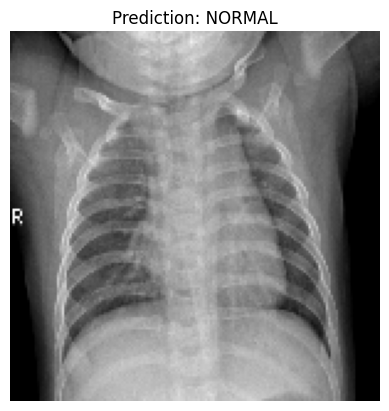

In [15]:
plt.imshow(images[0].numpy().astype("float32"))
plt.title("Prediction: " + class_names[predicted[0]])
plt.axis("off")
plt.show()